# Spiking Poisson Diffusion: Diffusion-Inspired Audio Denoising with Spiking Neural Networks

## Overview

This notebook presents a diffusion-inspired audio denoising framework implemented using Spiking Neural Networks (SNNs). The objective is to investigate whether spike-based neural systems can learn to reverse stochastic Poisson corruption applied across diffusion timesteps.

The framework combines:

- Poisson-based stochastic corruption
- Diffusion-style timestep conditioning
- Rate-coded spike encoding
- Spiking neural temporal processing
- Audio waveform reconstruction

The model performs noisy-to-clean waveform denoising on real speech samples from the Speech Commands dataset.

## Objectives

The primary objectives of this work are:

- Implement a stochastic forward corruption process using Poisson noise
- Train a spiking neural network conditioned on diffusion timesteps
- Reconstruct clean speech waveforms from corrupted audio
- Evaluate denoising performance using quantitative and qualitative analysis

## Motivation

Diffusion-inspired denoising frameworks have recently demonstrated strong performance in generative modeling and reconstruction tasks. At the same time, Spiking Neural Networks provide a biologically inspired and energy-efficient paradigm for temporal information processing.

This work explores whether spike-based neural systems can learn diffusion-style denoising objectives under stochastic Poisson corruption.

## Scope

This implementation focuses on validating diffusion-inspired denoising behavior rather than full probabilistic diffusion sampling.

The goal is to study:

- timestep-conditioned denoising
- stochastic Poisson corruption
- neuromorphic temporal reconstruction

within a spike-driven learning framework.

# Import Required Libraries

This section initializes the required libraries for:

- Deep learning with PyTorch
- Audio processing using torchaudio
- Spiking neural computation using snnTorch
- Visualization and waveform reconstruction

In [21]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

from torch.utils.data import DataLoader, Subset

import snntorch as snn
from snntorch import spikegen, surrogate

# Experiment Parameters

The following parameters define:

- Audio waveform length
- Number of diffusion timesteps
- SNN simulation timesteps
- Training epochs
- Batch size
- Poisson corruption intensity

In [22]:
# ========================= PARAMETERS =========================

L = 4000

diffusion_steps = 100

num_steps = 25

epochs = 15

batch_size = 64

sr = 16000

MAX_LAMBDA = 12.0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {DEVICE}")

Using device: cuda


# Poisson Forward Diffusion Process

The forward process progressively corrupts clean audio using timestep-conditioned Poisson stochasticity.

As the diffusion timestep increases:

- signal preservation decreases
- stochastic corruption increases

The corruption schedule follows an exponential decay formulation.

In [23]:
# ========================= POISSON FORWARD PROCESS =========================

def get_poisson_noised_sample(x0, t):

    """
    Poisson-based Forward Process
    """

    t = t.view(-1, 1).to(DEVICE)

    # Exponential signal preservation schedule

    gamma = torch.exp(
        -0.025 * t.float() * 6 / diffusion_steps
    )

    # Poisson rate

    rate = torch.clamp(
        x0 * (gamma * MAX_LAMBDA),
        min=0.5
    )

    # Poisson corruption

    noisy_counts = torch.poisson(rate)

    # Normalize to [0,1]

    noisy_norm = noisy_counts / (
        MAX_LAMBDA + 3.0
    )

    return torch.clamp(
        noisy_norm,
        0.0,
        1.0
    )

# Speech Commands Dataset

The Speech Commands dataset contains short spoken audio recordings and is commonly used for speech-related machine learning experiments.

A subset of 800 audio samples is used for lightweight experimentation and rapid prototyping.

# Audio Preprocessing Pipeline

The preprocessing pipeline performs:

- audio resampling
- mono conversion
- waveform padding/truncation
- waveform normalization

The output waveform is normalized to the range [0,1].

In [24]:
# ========================= DATASET =========================

class PoissonAudioDataset(torch.utils.data.Dataset):

    def __init__(self, subset):

        self.subset = subset

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, idx):

        waveform, sample_rate, *_ = self.subset[idx]

        # Resampling

        if sample_rate != sr:

            waveform = torchaudio.functional.resample(
                waveform,
                sample_rate,
                sr
            )

        # Mono conversion

        waveform = waveform.mean(dim=0)

        # Length correction

        if waveform.shape[0] < L:

            waveform = F.pad(
                waveform,
                (0, L - waveform.shape[0])
            )

        else:

            waveform = waveform[:L]

        # Normalize waveform

        waveform = (
            waveform - waveform.min()
        ) / (
            waveform.max() - waveform.min() + 1e-8
        )

        # IMPORTANT:
        # DO NOT MOVE TO GPU HERE

        return waveform

# Spiking Diffusion Model Architecture

The denoising model combines:

- timestep conditioning
- spike-based temporal encoding
- Leaky Integrate-and-Fire neurons
- continuous waveform reconstruction

The network predicts a denoised approximation of the clean waveform from stochastic Poisson-corrupted inputs.

# Time Embedding

A learned timestep embedding conditions the network on the current diffusion timestep.

This enables the model to adapt reconstruction behavior across varying corruption levels.

# Spiking Neural Denoiser

The model processes noisy audio using:

- rate-coded spike trains
- temporal membrane dynamics
- surrogate gradient learning

Leaky Integrate-and-Fire neurons are used for spike-based temporal processing.

In [25]:
# ========================= MODEL =========================

class SpikingPoissonDDPM(nn.Module):

    def __init__(
        self,
        input_dim=L,
        hidden=1024,
        beta=0.92
    ):

        super().__init__()

        # Time embedding

        self.time_mlp = nn.Sequential(

            nn.Linear(1, 256),

            nn.ReLU(),

            nn.Linear(256, 512),

            nn.ReLU(),

            nn.Linear(512, input_dim)

        )

        # Spiking layers

        self.fc1 = nn.Linear(
            input_dim,
            hidden
        )

        self.lif1 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(
            hidden,
            hidden
        )

        self.lif2 = snn.Leaky(
            beta=beta,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc_out = nn.Linear(
            hidden,
            input_dim
        )

    def forward(self, x_noisy, t):

        # Timestep conditioning

        t_emb = self.time_mlp(
            t.unsqueeze(-1).float() / diffusion_steps
        )

        x = x_noisy + t_emb

        # Rate coding

        spk_in = spikegen.rate(
            x,
            num_steps=num_steps
        )

        mem1 = self.lif1.init_leaky()

        mem2 = self.lif2.init_leaky()

        output_sum = 0

        for step in range(num_steps):

            cur1 = self.fc1(spk_in[step])

            spk1, mem1 = self.lif1(
                cur1,
                mem1
            )

            cur2 = self.fc2(spk1)

            spk2, mem2 = self.lif2(
                cur2,
                mem2
            )

            output_sum += self.fc_out(mem2)

        return torch.sigmoid(
            output_sum / num_steps
        )

# Dataset and DataLoader Construction

The DataLoader enables:

- mini-batch training
- randomized sampling
- GPU-efficient loading

In [26]:
# ========================= SETUP =========================

os.makedirs("./data", exist_ok=True)

base_dataset = torchaudio.datasets.SPEECHCOMMANDS(
    root="./data",
    download=True
)

subset = Subset(
    base_dataset,
    range(800)
)

dataset = PoissonAudioDataset(subset)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

model = SpikingPoissonDDPM().to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

# Training Objective

The model learns to reconstruct clean waveforms from timestep-conditioned stochastic Poisson corruption.

Training steps:

- sample random diffusion timestep
- apply forward Poisson corruption
- convert input into spike trains
- reconstruct clean waveform
- optimize reconstruction error

Mean Squared Error (MSE) is used as the denoising objective.

# Model Training

In [27]:
# ========================= TRAINING =========================

print("Starting Training - Poisson DDPM with SNN...\n")

loss_history = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x0 in loader:

        # MOVE BATCH TO GPU HERE

        x0 = x0.to(DEVICE)

        # Random diffusion timestep

        t = torch.randint(
            0,
            diffusion_steps,
            (x0.shape[0],),
            device=DEVICE
        )

        # Forward corruption

        noisy = get_poisson_noised_sample(
            x0,
            t
        )

        # Reverse denoising

        pred = model(
            noisy,
            t
        )

        # Reconstruction loss

        loss = loss_fn(
            pred,
            x0
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.5f}"
    )

print("\nTraining Completed!")

Starting Training - Poisson DDPM with SNN...

Epoch  1/15 | Loss: 0.02672
Epoch  2/15 | Loss: 0.01980
Epoch  3/15 | Loss: 0.01738
Epoch  4/15 | Loss: 0.01742
Epoch  5/15 | Loss: 0.01621
Epoch  6/15 | Loss: 0.01555
Epoch  7/15 | Loss: 0.01507
Epoch  8/15 | Loss: 0.01467
Epoch  9/15 | Loss: 0.01458
Epoch 10/15 | Loss: 0.01513
Epoch 11/15 | Loss: 0.01545
Epoch 12/15 | Loss: 0.01539
Epoch 13/15 | Loss: 0.01556
Epoch 14/15 | Loss: 0.01530
Epoch 15/15 | Loss: 0.01476

Training Completed!


# Training Loss Dynamics

The following plot visualizes the reduction in reconstruction loss during optimization.

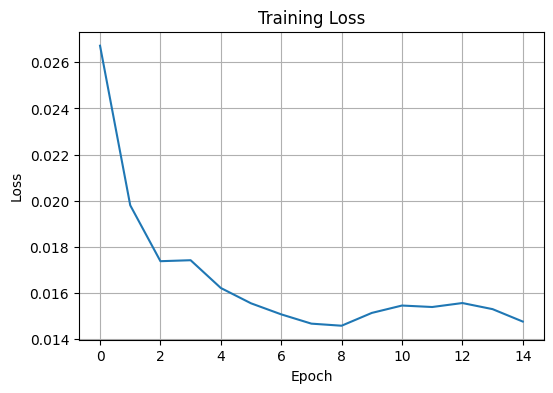

In [28]:
plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

# Quantitative Evaluation

To evaluate denoising quality:

- noisy waveform MSE is computed
- denoised waveform MSE is computed

A lower denoised MSE indicates successful learning of the reverse denoising objective.

In [29]:
# ========================= EVALUATION =========================

model.eval()

with torch.no_grad():

    x0 = next(iter(loader))

    # MOVE TO GPU HERE

    x0 = x0.to(DEVICE)

    test_t = torch.full(
        (x0.shape[0],),
        diffusion_steps // 2,
        device=DEVICE
    )

    # Forward corruption

    noisy = get_poisson_noised_sample(
        x0,
        test_t
    )

    # Denoising prediction

    denoised = model(
        noisy,
        test_t
    )

    denoised = torch.clamp(
        denoised,
        0,
        1
    )

    # MSE metrics

    mse_noisy = F.mse_loss(
        noisy,
        x0
    )

    mse_denoised = F.mse_loss(
        denoised,
        x0
    )

print(f"\nNoisy MSE:    {mse_noisy.item():.6f}")

print(f"Denoised MSE: {mse_denoised.item():.6f}")


Noisy MSE:    0.043567
Denoised MSE: 0.015193


# Qualitative Waveform Analysis

The following plots compare:

- original waveform
- Poisson-corrupted waveform
- denoised reconstruction

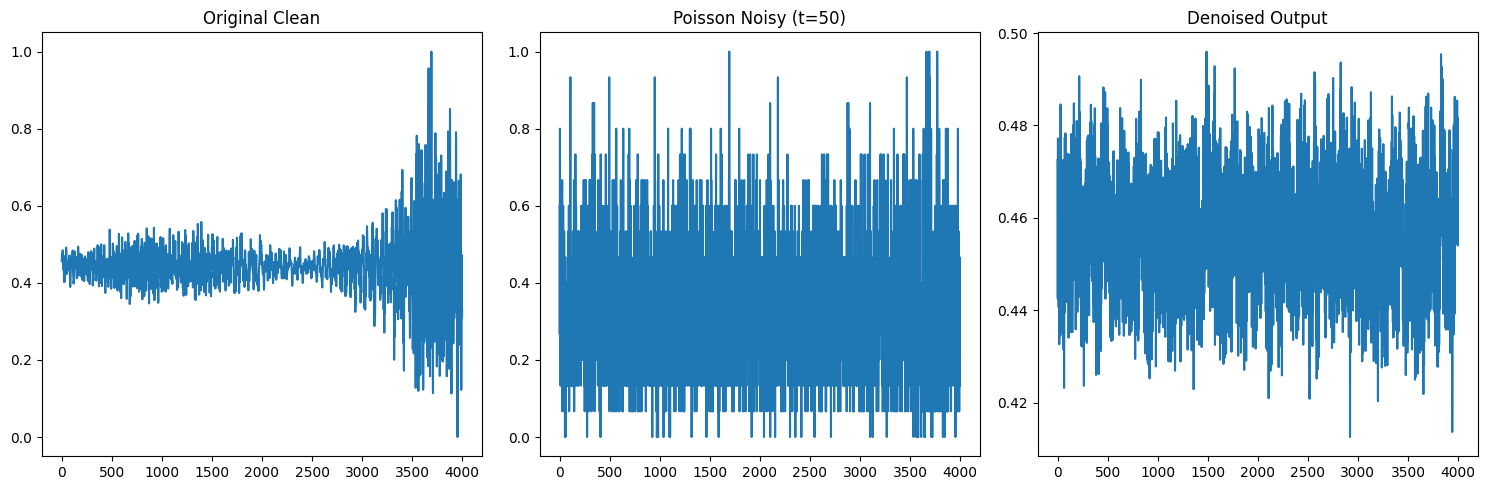

In [30]:
# ========================= VISUALIZATION =========================

idx = 0

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.plot(
    x0[idx].cpu().numpy()
)

plt.title("Original Clean")

plt.subplot(1,3,2)

plt.plot(
    noisy[idx].cpu().numpy()
)

plt.title(
    f"Poisson Noisy (t={diffusion_steps//2})"
)

plt.subplot(1,3,3)

plt.plot(
    denoised[idx].cpu().numpy()
)

plt.title("Denoised Output")

plt.tight_layout()

plt.show()

# Audio Reconstruction

The original, noisy, and denoised audio waveforms are saved locally for qualitative listening analysis.

In [31]:
# ========================= SAVE AUDIO =========================

clean_audio = x0[idx].cpu().numpy()

denoised_audio = denoised[idx].cpu().numpy()

sf.write(
    "original_audio.wav",
    clean_audio,
    sr
)

sf.write(
    "noisy_audio.wav",
    noisy[idx].cpu().numpy(),
    sr
)

sf.write(
    "denoised_audio.wav",
    denoised_audio,
    sr
)

print(
    "Audio files saved: original, noisy, denoised"
)

Audio files saved: original, noisy, denoised


# Conclusion

This study demonstrates that a spiking neural network can learn to partially reverse timestep-conditioned Poisson corruption on real speech waveforms.

## Key Findings

- The model learns stochastic denoising under Poisson corruption
- Denoised outputs achieve lower reconstruction error than noisy inputs
- Spike-based temporal processing can support diffusion-inspired denoising objectives

## Insights

The reduction in denoised MSE suggests that spike-driven neural systems can learn meaningful reverse reconstruction behavior under stochastic corruption schedules.

## Limitations

- The implementation does not perform full iterative diffusion sampling
- Training is computationally expensive due to temporal spike simulation
- Reconstruction quality depends strongly on noise scheduling and dataset size

## Future Directions

Potential future improvements include:

- iterative reverse sampling
- deeper spiking architectures
- alternative spike encoding schemes
- full probabilistic diffusion sampling
- neuromorphic hardware deployment

## Takeaway

This work provides a proof-of-concept that diffusion-inspired stochastic denoising can be implemented using spike-based neural systems for audio reconstruction tasks.